# Inference Analysis

This Jupyter notebook allows us to check various metrics of the inference results obtained from our model. 

In [1]:
#Importing relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from helper_code.dataloading import get_data_urls

This repository contains example data from a previous test on the dataset used to train the final model. 

The data containing the ground-truth labels can be found in the `camera_data` folder under the name `training_set_cameras_data.csv`

The results from inference can be found in the `outputs` folder under the names `inference_results_example.csv` and `throughput_results_example.csv`.

If you wish to analyze the model's results on a different dataset, follow these steps:

1) Ensure you have a dataset in the proper format. Two additional datasets, `coronado_hills_data.csv` and `unseen_cameras_data.csv` are provided in the `camera_data` folder.

2) Run `run_inference.py` to obtain inference and throughput results. If you wish to change the default behavior of this script, you can view the documentation for the arguments by running `python run_inference.py -h`

In [ ]:
use_example_data = True #Set this to False if you want to use different data 

if use_example_data:
    throughput_fp = "outputs/throughput_results_example.csv"
    inference_fp = "outputs/inference_results_example.csv"
    data_fp  = "camera_data/training_set_cameras_data.csv"
else:
    throughput_fp = "outputs/throughput_results.csv"
    inference_fp = "outputs/inference_results.csv"
    data_fp  = "" #Set this to the dataset you used when running run_inference.py. The default is "camera_data/training_set_cameras_data.csv"

In [4]:
throughput_data = pd.read_csv(throughput_fp, names = ["Batch Size", "Time Per Batch (Loading)", 
                                                      "Time Per Batch (Inference)", 
                                                      "Total Time Per Batch", "Overall Total"])
throughput_data.head()

,Batch Size,Time Per Batch (Loading),Time Per Batch (Inference),Total Time Per Batch,Overall Total
0,5,0.6563,0.0098,0.6661,835.3257
1,10,0.5706,0.0106,0.5811,364.3772
2,15,0.9590,0.0110,0.9701,405.4874
3,20,1.2616,0.0114,1.2730,399.7254
4,25,1.5938,0.0115,1.6053,402.9395


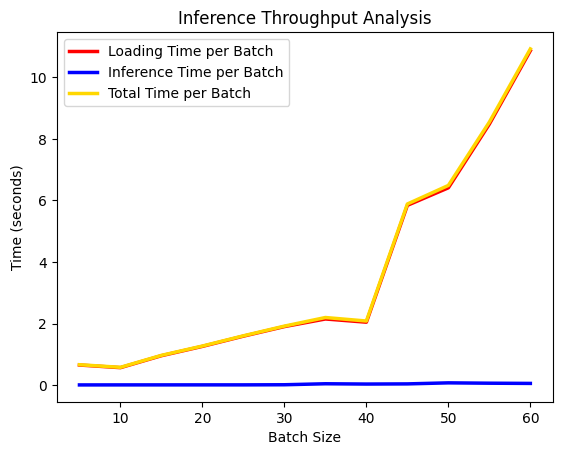

In [5]:
plt.plot(throughput_data["Batch Size"], throughput_data["Time Per Batch (Loading)"], color = "red", lw = 2.5, label="Loading Time per Batch")
plt.plot(throughput_data["Batch Size"], throughput_data["Time Per Batch (Inference)"], color = "blue", lw = 2.5, label="Inference Time per Batch")
plt.plot(throughput_data["Batch Size"], throughput_data["Total Time Per Batch"], color = "gold", lw = 2.5, label="Total Time per Batch")
plt.xlabel("Batch Size")
plt.ylabel("Time (seconds)")
plt.title("Inference Throughput Analysis")
plt.legend()

In [5]:
inference_data = pd.read_csv(inference_fp, sep = ",", header = None, names = ["id", "img_url", "img_path", "predicted_label", "predicted_label_name"])
inference_data.head()

,id,img_url,img_path,predicted_label,predicted_label_name
0,1081399,https://tools.alertcalifornia.org/fireframes5/...,camera_data/images/img_1081399.jpg,1,Abnormal
1,1081402,https://tools.alertcalifornia.org/fireframes5/...,camera_data/images/img_1081402.jpg,0,Normal
2,1081408,https://tools.alertcalifornia.org/fireframes5/...,camera_data/images/img_1081408.jpg,0,Normal
3,1081413,https://tools.alertcalifornia.org/fireframes5/...,camera_data/images/img_1081413.jpg,0,Normal
4,1081414,https://tools.alertcalifornia.org/fireframes5/...,camera_data/images/img_1081414.jpg,0,Normal


In [ ]:
camera_data = get_data_urls(data_fp, binarize = True, include_location=True)
camera_data.head()

,choice,image,id,location
0,1,https://tools.alertcalifornia.org/fireframes5/...,1081399,CoronadoHillsS
1,0,https://tools.alertcalifornia.org/fireframes5/...,1081402,CoronadoHillsS
2,0,https://tools.alertcalifornia.org/fireframes5/...,1081408,CoronadoHillsS
3,0,https://tools.alertcalifornia.org/fireframes5/...,1081413,CoronadoHillsS
4,0,https://tools.alertcalifornia.org/fireframes5/...,1081414,CoronadoHillsS


In [13]:
def plot_confusion_matrix(true_labels, pred_labels, title):
    cm = confusion_matrix(true_labels, pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Abnormal"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

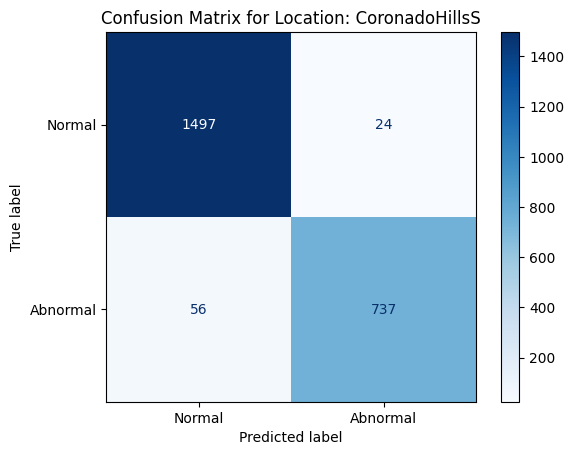

Accuracy for CoronadoHillsS: 0.9654


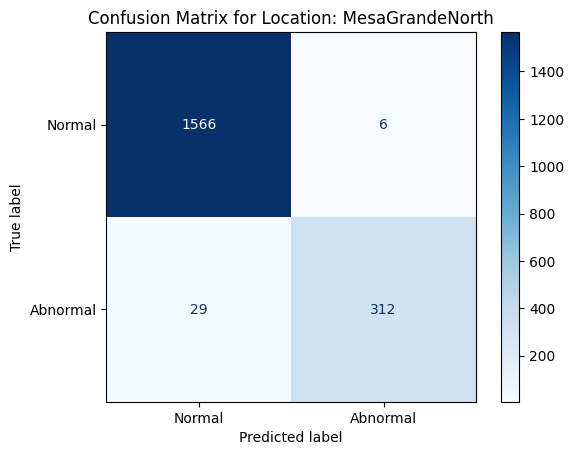

Accuracy for MesaGrandeNorth: 0.9817


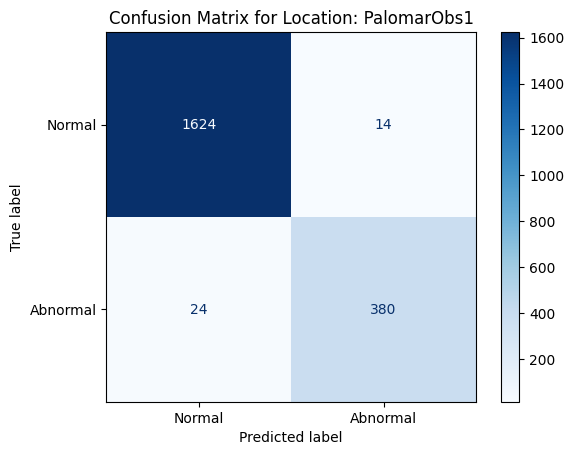

Accuracy for PalomarObs1: 0.9814


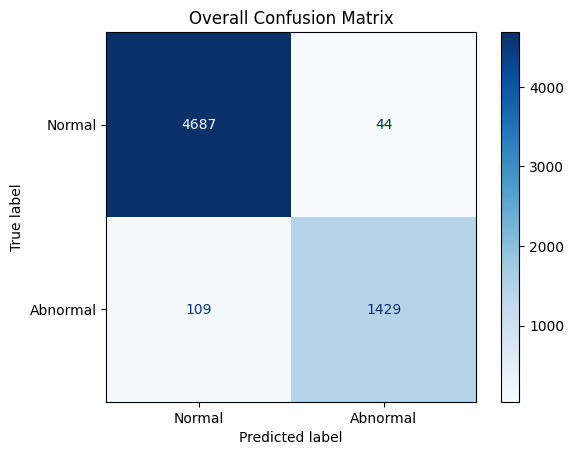

Overall Accuracy: 0.9756


In [14]:
choice_and_predictions = pd.merge(camera_data, inference_data, left_on = "id", right_on = "id", how = "inner")

for location in choice_and_predictions["location"].unique():
    subset = choice_and_predictions[choice_and_predictions["location"] == location]
    plot_confusion_matrix(subset['choice'], subset['predicted_label'], title=f"Confusion Matrix for Location: {location}")
    print(f"Accuracy for {location}: {(subset['choice'] == subset['predicted_label']).mean():.4f}")

plot_confusion_matrix(choice_and_predictions['choice'], choice_and_predictions['predicted_label'], title=f"Overall Confusion Matrix")
print(f"Overall Accuracy: {(choice_and_predictions['choice'] == choice_and_predictions['predicted_label']).mean():.4f}")